In [ ]:
"""
Cat vs Dog Image Classification using Custom 4-Block CNN
Achieved 92.96% Accuracy with Advanced Regularization
"""

'\nCat vs Dog Image Classification using Custom 4-Block CNN\nAchieved 92.96% Accuracy with Advanced Regularization\n'

In [ ]:
# ==============================================================================
# 1. ENVIRONMENT SETUP & DATA DOWNLOAD
# ==============================================================================
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Downloading dataset from Kaggle
!kaggle datasets download -d salader/dogs-vs-cats

import zipfile
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Dropout, Dense, GlobalAveragePooling2D
from tensorflow.keras import regularizers, optimizers, callbacks
from sklearn.metrics import confusion_matrix, classification_report

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata


In [ ]:
# Extracting the dataset
with zipfile.ZipFile('/content/dogsvscats.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

# ==============================================================================
# 2. DATA LOADING & PIPELINE OPTIMIZATION
# ==============================================================================
# Loading raw data from directories
raw_train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels="inferred",
    label_mode="int",
    batch_size=64,
    image_size=(150, 150)
)

raw_val_ds = keras.utils.image_dataset_from_directory(
    directory='/content/test',
    labels="inferred",
    label_mode="int",
    batch_size=64,
    image_size=(150, 150)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [ ]:
# Preventing Data Leakage: Splitting the test directory into Validation and Test sets
val_batches = tf.data.experimental.cardinality(raw_val_ds)
validation_ds = raw_val_ds.take(val_batches // 2)
test_ds = raw_val_ds.skip(val_batches // 2)

# Normalization Function
def process(image, label):
    image = tf.cast(image / 255.0, tf.float32)
    return image, label

In [ ]:
# Applying optimization pipeline (Mapping, Caching and Prefetching)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = raw_train_ds.map(process).cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.map(process).cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.map(process).cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
# ==============================================================================
# 3. MODEL ARCHITECTURE (Custom 4-Block CNN)
# ==============================================================================
model = Sequential([
    Input(shape=(150, 150, 3)),

    # Block 1
    Conv2D(64, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2), strides=2),

    # Block 2
    Conv2D(128, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2), strides=2),

    # Block 3
    Conv2D(256, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2), strides=2),

    # Block 4 (Crucial for learning deep spatial features)
    Conv2D(512, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2), strides=2),

    # Classification Head (Using GAP instead of Flatten to minimize parameter explosion)
    GlobalAveragePooling2D(),
    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

In [ ]:
# ==============================================================================
# 4. COMPILATION & TRAINING WITH CALLBACKS
# ==============================================================================
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Training Callbacks for dynamic optimization
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [ ]:
# Executing model training
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=validation_ds,
    callbacks=[early_stopping, lr_scheduler]
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 246ms/step - accuracy: 0.6787 - loss: 1.5118 - val_accuracy: 0.4904 - val_loss: 2.5753 - learning_rate: 1.0000e-04
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 164ms/step - accuracy: 0.7387 - loss: 1.3572 - val_accuracy: 0.6154 - val_loss: 1.5631 - learning_rate: 1.0000e-04
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 161ms/step - accuracy: 0.7749 - loss: 1.2410 - val_accuracy: 0.7228 - val_loss: 1.2908 - learning_rate: 1.0000e-04
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 162ms/step - accuracy: 0.8090 - loss: 1.1254 - val_accuracy: 0.8101 - val_loss: 1.0976 - learning_rate: 1.0000e-04
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 162ms/step - accuracy: 0.8396 - loss: 1.0141 - val_accuracy: 0.8546 - val_loss: 0.9741 - learning_rate: 1.0000e-04
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 161ms/step - accuracy: 0.8712 - loss: 0.9056 - val_accuracy: 0.8682 - val_loss: 0.8989 - learning_rate: 1.0000e-04
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 16

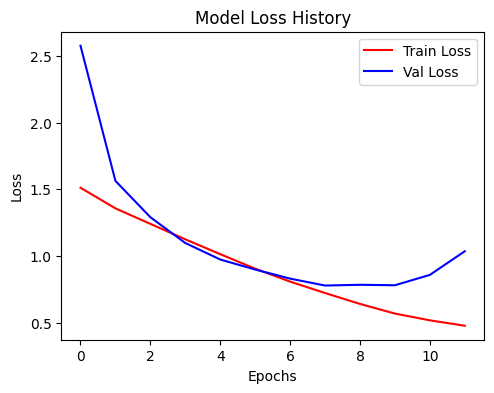

In [ ]:
# ==============================================================================
# 5. EVALUATION AND PERFORMANCE METRICS
# ==============================================================================
# Plotting Loss Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], color='red', label='Train Loss')
plt.plot(history.history['val_loss'], color='blue', label='Val Loss')
plt.title('Model Loss History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

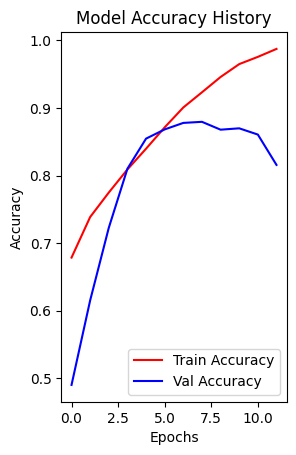

In [ ]:
# Plotting Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], color='red', label='Train Accuracy')
plt.plot(history.history['val_accuracy'], color='blue', label='Val Accuracy')
plt.title('Model Accuracy History')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Final Evaluation on the Unseen Test Dataset
test_loss, test_accuracy = model.evaluate(test_ds)
print("\n🎯 --- FINAL UNSEEN TEST RESULTS ---")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8834 - loss: 0.7877

🎯 --- FINAL UNSEEN TEST RESULTS ---
Test Loss: 0.7877
Test Accuracy: 88.34%


In [ ]:
# Generating Classification Report & Confusion Matrix
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())



print("\n📊 Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print("\n📋 Detailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Cat', 'Dog']))


📊 Confusion Matrix:
[[1106  173]
 [ 119 1106]]

📋 Detailed Classification Report:
              precision    recall  f1-score   support

         Cat       0.90      0.86      0.88      1279
         Dog       0.86      0.90      0.88      1225

    accuracy                           0.88      2504
   macro avg       0.88      0.88      0.88      2504
weighted avg       0.88      0.88      0.88      2504



In [ ]:
# ==============================================================================
# 6. VISUALIZING MISCLASSIFIED SAMPLES (ERROR ANALYSIS)
# ==============================================================================
misclassified_cats = []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0).flatten()
    pred_labels = (preds > 0.5).astype(int)
    for i in range(len(labels)):
        if labels[i].numpy() == 0 and pred_labels[i] == 1:  # True: Cat, Predicted: Dog
            misclassified_cats.append(images[i].numpy())

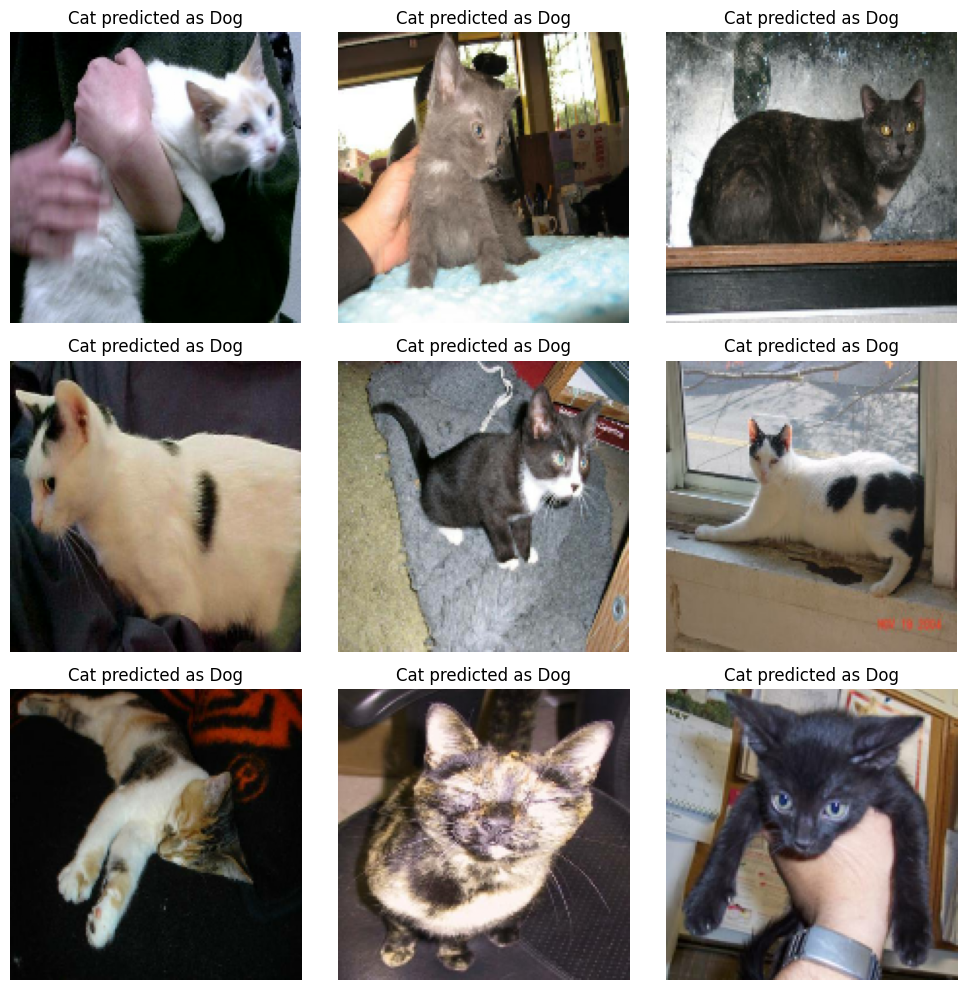

In [ ]:
# Displaying the first 9 misclassified cats
if misclassified_cats:
    plt.figure(figsize=(10, 10))
    for i, img in enumerate(misclassified_cats[:9]):
        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title("Cat predicted as Dog")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified samples found in the analyzed batches!")

In [ ]:
# Saving the final model weights for production deployment
model.save('cats_vs_dogs_custom_cnn.h5')
print("💾 Model successfully saved as 'cats_vs_dogs_custom_cnn.h5'")

💾 Model successfully saved as 'cats_vs_dogs_custom_cnn.h5'
